#### Business Introduction;
##### MetroMove Transit Solutions is a public transportation service provider operating in multiple cities. 
##### They manage and analyze thousands of daily trips taken via buses, trains, ferries, and trams. 
##### The company's mission is to provide efficient, affordable, and timely public transportation services while leveraging data to improve passenger experience and optimize operations.

#### Problem Statement;
##### MetroMove has collected a large volume of trip data but lacks insights into trip performance, passenger behavior, and fare patterns due to messy, inconsistent, and incomplete records.
##### As part of their new data-driven initiative, they want to clean, explore, and summarize their trip records to identify inefficiencies and patterns that can drive operational improvements.


In [1]:
#Fisrt, install and import all the necessary libraries;

! pip install missingno

import pandas as pd                # for data processing
import numpy as np                    # for data processing
import matplotlib.pyplot as plt   # for data visualization
import seaborn as sns            # for data visualization
import plotly.express as px      # for data visualization
import missingno as msno          # for missing data visualization
import collections as Counter      # for counting
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Load the Dataset;
data = pd.read_excel(r"C:\Users\Muoghalu\Downloads\DATA SCIENCE TRAINING BY 10ALYTICS\Public_Transport_Trips_EDA.xlsx")

#### Data Exploration and Cleaning;

In [3]:
# Print the top rows;
data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [4]:
# Print the bottom rows;
data.tail()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
995,TRIP0996,train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday,NaN,NaN
996,TRIP0997,Bus,Central,West End,2024-01-01 22:36:00,63.0,7.772635,35.0,2024-02-11,Thursday,NaN,NaN
997,TRIP0998,FERRY,West End,North Station,2024-01-01 22:37:00,23.0,NaN,8.0,2024-02-11,Saturday,NaN,NaN
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9.0,43.300617,169.0,2024-02-11,Sunday,NaN,NaN
999,TRIP1000,train,Airport,West End,2024-01-01 22:39:00,34.0,8.168803,21.0,2024-02-11,Tuesday,NaN,NaN


In [5]:
# Dimensionality of the data; number of rows and columns;
data.shape

(1000, 12)

In [6]:
# To examine the columns/features of the data;
data.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [7]:
# To investigate the dataset for anomalies and data types;
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 93.9+

In [8]:
# Investigate the missing data; to sum all the missing data;
null_vals = data.isnull().sum()
null_vals

Trip_ID                     0
Mode_of_Transport           0
Departure_Station           0
Arrival_Station             0
Departure_Time              0
Passenger_Count           100
Fare_Amount               100
Trip_Duration_Minutes     100
Trip_Date                   0
Day_of_Week                 0
Unnamed: 10              1000
Unnamed: 11               701
dtype: int64

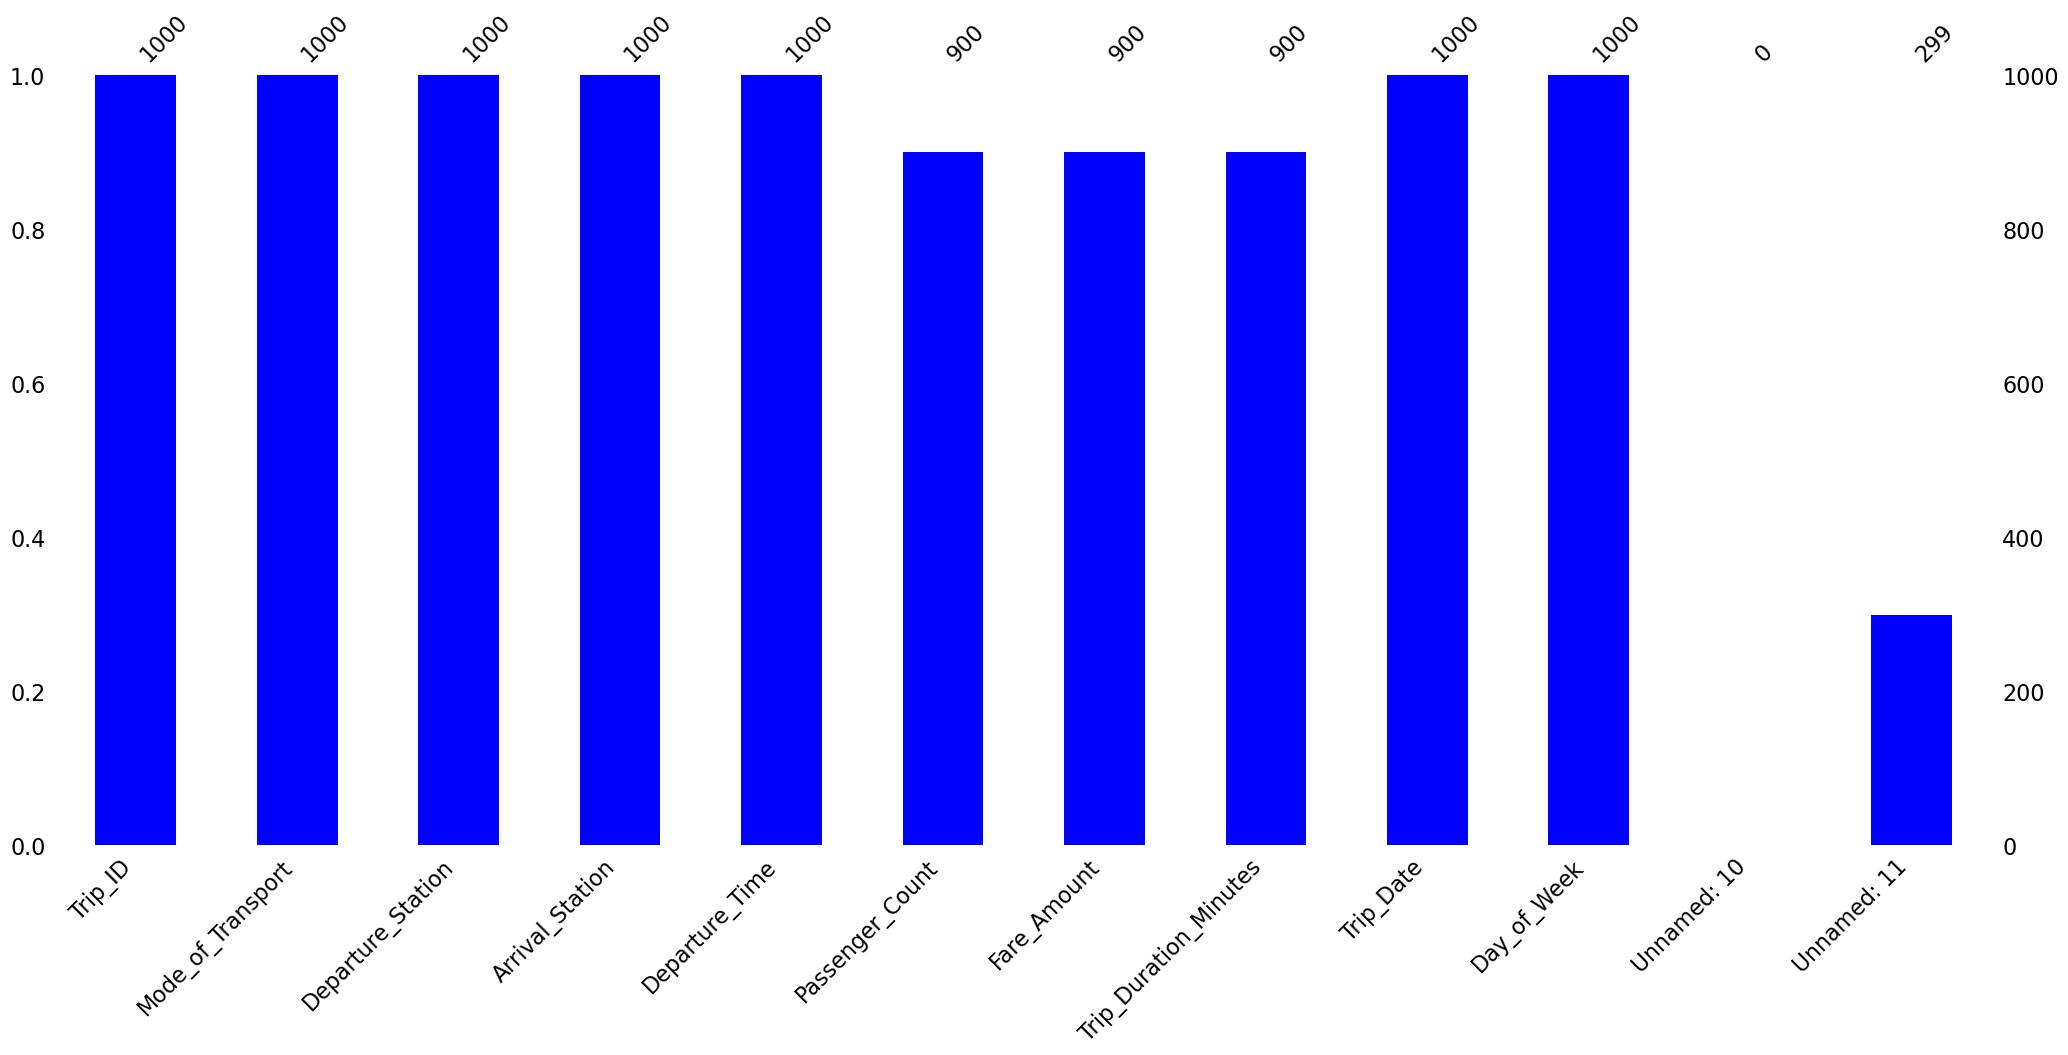

In [9]:
# To visualize the missing data using missingno(msno);
msno.bar(data,color='blue');

In [10]:
# To check for duplicates in the data;
data.duplicated().sum()

np.int64(0)

In [11]:
# To check for inconsistent data type;
data.dtypes

Trip_ID                          object
Mode_of_Transport                object
Departure_Station                object
Arrival_Station                  object
Departure_Time           datetime64[ns]
Passenger_Count                 float64
Fare_Amount                     float64
Trip_Duration_Minutes           float64
Trip_Date                datetime64[ns]
Day_of_Week                      object
Unnamed: 10                     float64
Unnamed: 11                      object
dtype: object

In [12]:
data.ndim

2

In [13]:
# to select all the data that are numbers from the dataset;
data.select_dtypes(include='number')

,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Unnamed: 10
0,21.0,4.343642,26.0,NaN
1,46.0,20.673380,134.0,NaN
2,91.0,NaN,NaN,NaN
3,27.0,3.767487,NaN,NaN
4,66.0,NaN,NaN,NaN
...,...,...,...,...
995,NaN,40.546670,51.0,NaN
996,63.0,7.772635,35.0,NaN
997,23.0,NaN,8.0,NaN
998,9.0,43.300617,169.0,NaN


In [14]:
# to select all the data that are texts from the dataset;
data.select_dtypes(include='object')

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,Sunday,F
1,TRIP0002,Tram,North Station,Downtown,Saturday,F
2,TRIP0003,bus,Central,North Station,Tuesday,F
3,TRIP0004,FERRY,Downtown,Central,Sunday,F
4,TRIP0005,Ferry,Downtown,Central,Monday,F
...,...,...,...,...,...,...
995,TRIP0996,train,North Station,West End,Saturday,NaN
996,TRIP0997,Bus,Central,West End,Thursday,NaN
997,TRIP0998,FERRY,West End,North Station,Saturday,NaN
998,TRIP0999,Tram,South Point,Central,Sunday,NaN


In [15]:
# To drop the columns with so much missing data;
data.drop(columns=['Unnamed: 10', 'Unnamed: 11'], inplace= True)

In [16]:
# To fill the columns with not so much missing values;
data['Passenger_Count'].isnull().sum()

np.int64(100)

In [17]:
data['Passenger_Count'].unique()

array([21., 46., 91., 27., 66., 41., 13.,  9., 36., 86., 90., 58., 54.,
       12., 81., 78., 14., 34., 53., 20., 75., 16., 95., 70., 56., 83.,
        4., nan, 24., 26., 37., 85., 74., 38., 60., 57., 45., 17., 71.,
        3., 88., 80., 55., 30., 82., 19., 31., 49., 63., 22., 76., 64.,
       48., 94., 18., 92., 47., 15., 69., 61., 10., 50., 77., 42., 35.,
       93., 84.,  5., 39., 89.,  7., 44., 73., 68., 33., 32., 87., 98.,
       28., 43., 65.,  2., 51., 40., 59., 99., 79., 25., 72., 97.,  6.,
       52., 23., 11.,  8.,  1., 62., 67., 96., 29.])

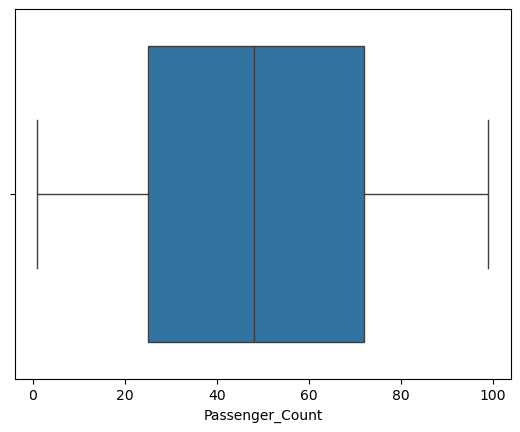

In [18]:
# To check if it has outliers and know whether to fill with mean or median(if there are outliers);
sns.boxplot(data, x='Passenger_Count');

In [19]:
# the output shows no outliers , so we fill with mean;
data['Passenger_Count'].mean().round()


np.float64(49.0)

In [20]:
# the output shows no outliers , so we fill with mean;
data['Fare_Amount'].mean().round(2)

np.float64(25.36)

In [21]:
# the output shows no outliers , so we fill with mean;
data['Trip_Duration_Minutes'].mean().round()

np.float64(94.0)

In [22]:
# To fill in with the mean value;
data['Passenger_Count'].fillna(data['Passenger_Count'].mean().round(), inplace = True)
data['Fare_Amount'].fillna(data['Fare_Amount'].mean().round(2), inplace = True)
data['Trip_Duration_Minutes'].fillna(data['Trip_Duration_Minutes'].mean().round(), inplace = True)

In [23]:
# To round up the figures in the columns;
data['Fare_Amount'] = data['Fare_Amount'].round(decimals=2)

In [24]:

data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.34,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.67,134.0,2024-01-01,Saturday
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,25.36,94.0,2024-01-01,Tuesday
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.77,94.0,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.36,94.0,2024-01-01,Monday


In [25]:
data.isnull().sum()

Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
dtype: int64

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 78.3+ KB


In [27]:
# To convert column- Passenger Count and Trip Duration Minutes to  an integer;
data = data.astype({'Passenger_Count' : int, 'Trip_Duration_Minutes' : int})
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        1000 non-null   int64         
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   int64         
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 78.3+ KB


In [28]:
# To replace inconsistent texts in the mode of transport column;
data['Mode_of_Transport'].unique()

array(['FERRY', 'Tram', 'bus', 'Ferry', 'fErry', 'Train', 'train', 'BUS',
       'Bus'], dtype=object)

In [29]:
data['Mode_of_Transport'] = data['Mode_of_Transport'].str.replace('FERRY' , 'Ferry')   

In [30]:
data['Mode_of_Transport'] = data['Mode_of_Transport'].str.replace('fErry' , 'Ferry')  

In [31]:
data['Mode_of_Transport'] = data['Mode_of_Transport'].str.replace(  'bus' , 'Bus')  

In [32]:
data['Mode_of_Transport'] = data['Mode_of_Transport'].str.replace(  'BUS' , 'Bus') 

In [33]:
data['Mode_of_Transport'] = data['Mode_of_Transport'].str.replace(  'train' , 'Train') 

In [34]:
data['Mode_of_Transport'].unique()

array(['Ferry', 'Tram', 'Bus', 'Train'], dtype=object)

In [35]:
data['Departure_Station'].unique()

array(['West End', 'North Station', 'Central', 'Downtown', 'South Point',
       ' Central ', 'Airport'], dtype=object)

In [36]:
data['Departure_Station'] = data['Departure_Station'].str.replace(  ' Central ' , 'Central') 

In [37]:
data['Arrival_Station'].unique()

array(['airport', 'Downtown', 'North Station', 'Central', 'South Point',
       'West End', 'Airport'], dtype=object)

In [38]:
data['Arrival_Station'] = data['Arrival_Station'].str.replace(  'airport' , 'Airport') 

In [39]:
data['Departure_Station'].unique()

array(['West End', 'North Station', 'Central', 'Downtown', 'South Point',
       'Airport'], dtype=object)

In [40]:
data['Arrival_Station'].unique()

array(['Airport', 'Downtown', 'North Station', 'Central', 'South Point',
       'West End'], dtype=object)

### Statistical Analysis;

In [41]:
#Datetime Analysis;
data.tail(2)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9,43.30,169,2024-02-11,Sunday
999,TRIP1000,Train,Airport,West End,2024-01-01 22:39:00,34,8.17,21,2024-02-11,Tuesday


In [42]:
# Then, to extract the year, month, quarter; and create new columns for them;


data['Departure_Hour']=data['Departure_Time'].dt.hour
data['Departure_Day_Name']=data['Departure_Time'].dt.day_name()
data['Departure_Year']=data['Departure_Time'].dt.year
data['Departure_Month_Name']=data['Departure_Time'].dt.month_name()

data['Trip_Year']=data['Trip_Date'].dt.year
data['Trip_Month_Name']=data['Trip_Date'].dt.month_name()

In [43]:
data['Departure_Hour'].unique()

array([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22],
      dtype=int32)

In [44]:
# To create Departure Time Category column;
def tc(x):
    if 6 <= x['Departure_Hour'] <= 13:
        return 'Morning'
    elif 14 <= x['Departure_Hour'] <= 18:
        return 'Afternoon'
    elif 19 <= x['Departure_Hour'] <= 21:
        return 'Evening'
    else:
        return 'Night'

data['Departure_Time_Category'] = data.apply(tc, axis=1)

In [45]:
# Numerical Statistical Analysis;
data.describe()

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Departure_Hour,Departure_Year,Trip_Year
count,1000,1000.000000,1000.00000,1000.000000,1000,1000.000000,1000.0,1000.0
mean,2024-01-01 14:19:30,49.139000,25.36069,94.243000,2024-01-21 08:03:50.400000,13.840000,2024.0,2024.0
min,2024-01-01 06:00:00,1.000000,0.50000,5.000000,2024-01-01 00:00:00,6.000000,2024.0,2024.0
25%,2024-01-01 10:09:45,28.000000,13.91750,55.000000,2024-01-11 00:00:00,10.000000,2024.0,2024.0
50%,2024-01-01 14:19:30,49.000000,25.36000,94.000000,2024-01-21 00:00:00,14.000000,2024.0,2024.0
75%,2024-01-01 18:29:15,70.000000,36.58000,132.250000,2024-02-01 00:00:00,18.000000,2024.0,2024.0
max,2024-01-01 22:39:00,99.000000,49.95000,179.000000,2024-02-11 00:00:00,22.000000,2024.0,2024.0
std,NaN,26.275465,13.72166,48.033959,NaN,4.816388,0.0,0.0


In [46]:
# Categorical Statistical Analysis;
data.describe(include=['object', 'bool'])

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week,Departure_Day_Name,Departure_Month_Name,Trip_Month_Name,Departure_Time_Category
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,4,6,6,7,1,1,2,4
top,TRIP0001,Bus,Central,Airport,Sunday,Monday,January,January,Morning
freq,1,332,208,213,167,1000,1000,744,480


In [47]:
# To create new columns- Destination and Revenue;
data['Destination'] = data['Departure_Station'] + ' To ' + data['Arrival_Station']
data['Destination'].value_counts()

Destination
North Station To Airport          44
Central To Airport                40
Central To North Station          37
Airport To Airport                37
Central To South Point            37
West End To Airport               34
North Station To Downtown         33
Airport To West End               33
Central To Downtown               33
Central To Central                32
Downtown To Downtown              32
South Point To Airport            31
South Point To West End           30
Downtown To South Point           29
North Station To South Point      29
Central To West End               29
West End To South Point           29
Airport To Downtown               28
Downtown To Central               28
North Station To Central          27
Downtown To Airport               27
Downtown To West End              26
West End To North Station         26
West End To Central               25
South Point To Central            25
Downtown To North Station         25
South Point To South Point

In [48]:
data['Revenue'] = data['Fare_Amount'] * data['Passenger_Count']
data['Revenue'].value_counts()

Revenue
1242.64    11
1191.92     4
938.32      4
532.56      3
380.40      3
           ..
307.08      1
228.47      1
1869.44     1
830.06      1
277.78      1
Name: count, Length: 958, dtype: int64

#### Univariate Analysis;

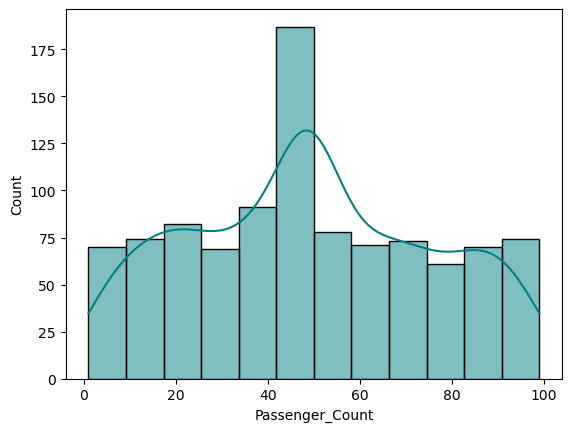

In [49]:
# Distribution of Passenger Count;

sns.histplot(data, x= 'Passenger_Count', kde = True, color ='teal');

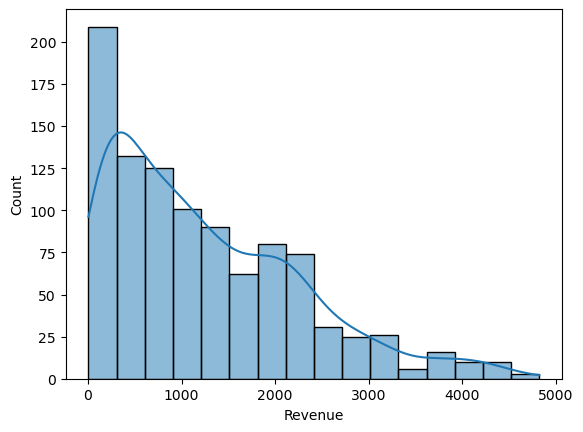

In [50]:
# Distribution of Revenue;

sns.histplot(data, x= 'Revenue', kde = True);

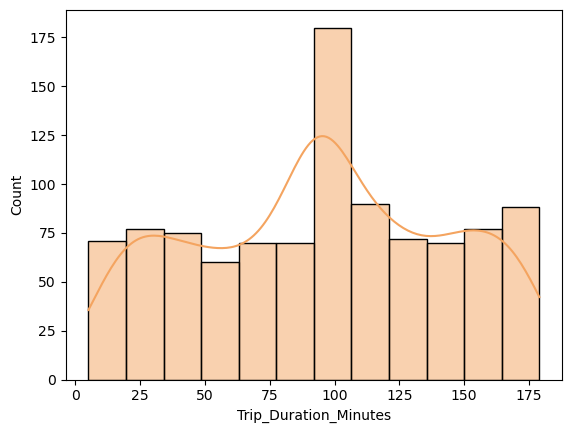

In [51]:
# Distribution of Trip Duration Minutes;
sns.histplot(data, x= 'Trip_Duration_Minutes', kde = True, color ='sandybrown');

#### Bivariate Analysis

In [52]:
data['Revenue'] = data['Fare_Amount'] * data['Passenger_Count']
data['Revenue'].value_counts()

Revenue
1242.64    11
1191.92     4
938.32      4
532.56      3
380.40      3
           ..
307.08      1
228.47      1
1869.44     1
830.06      1
277.78      1
Name: count, Length: 958, dtype: int64

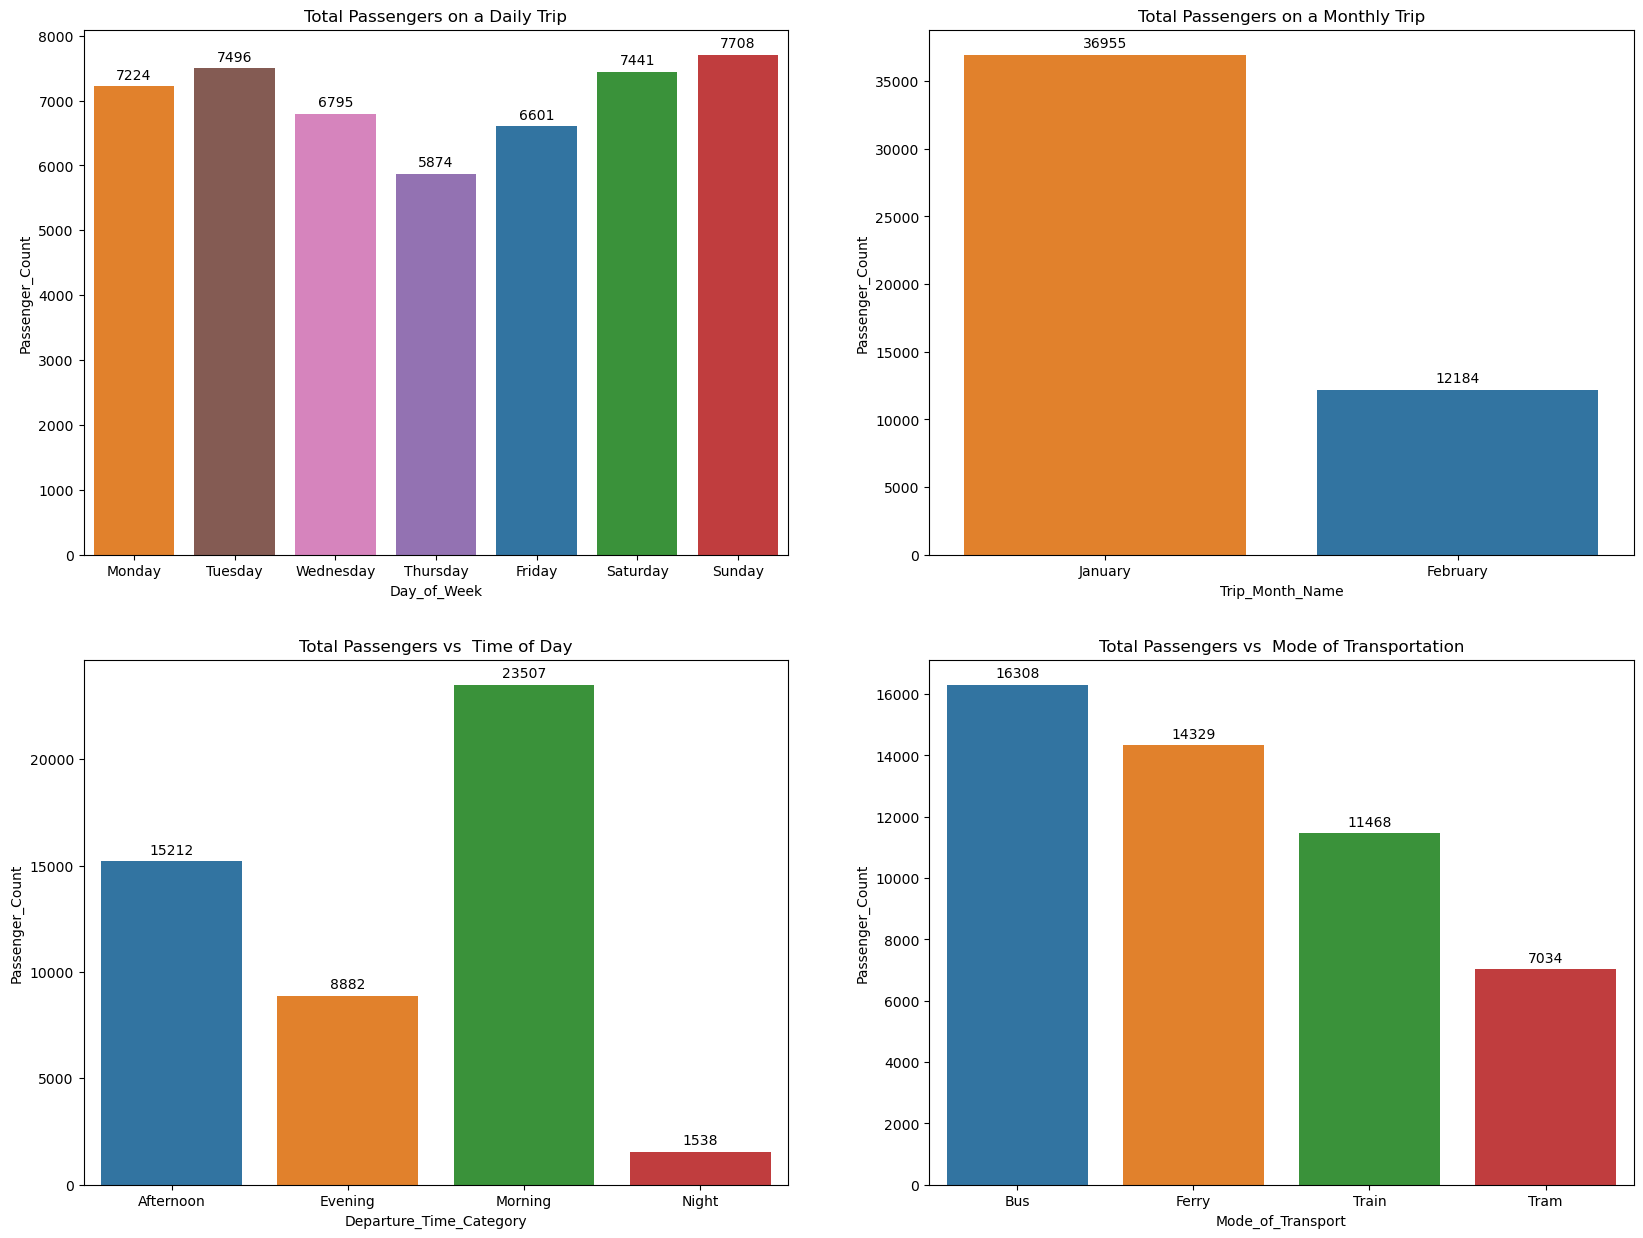

In [53]:
fig,axs = plt.subplots(nrows = 2, ncols = 2, figsize =(20, 15))

week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February']


# How many Passengers travel daily?
daily_trips = data.groupby('Day_of_Week')['Passenger_Count'].sum().reset_index()
sns.barplot(x= 'Day_of_Week', data = daily_trips, y = 'Passenger_Count', hue = 'Day_of_Week', order = week_order,  ax=axs[0,0])
for container in axs[0,0].containers:
    axs[0,0].bar_label(container,padding =3)
axs[0,0].set_title('Total Passengers on a Daily Trip');

# How many Passengers travel monthly?
monthly_trips = data.groupby('Trip_Month_Name')['Passenger_Count'].sum().reset_index()
sns.barplot(x= 'Trip_Month_Name', data = monthly_trips, y = 'Passenger_Count',hue = 'Trip_Month_Name', order = month_order, ax=axs[0,1])
for container in axs[0,1].containers:
    axs[0,1].bar_label(container,padding =3)
axs[0,1].set_title('Total Passengers on a Monthly Trip');

# What time of day records the highest number of Passengers?
trip_time = data.groupby('Departure_Time_Category')['Passenger_Count'].sum().reset_index()
sns.barplot(x= 'Departure_Time_Category', data = trip_time, y = 'Passenger_Count',hue = 'Departure_Time_Category', ax=axs[1,0])
for container in axs[1,0].containers:
    axs[1,0].bar_label(container,padding =3)
axs[1,0].set_title('Total Passengers vs  Time of Day');

# What mode of transportation records the highest number of Passengers?
trans_mode = data.groupby('Mode_of_Transport')['Passenger_Count'].sum().reset_index()
sns.barplot(x= 'Mode_of_Transport', data = trans_mode, y = 'Passenger_Count', hue = 'Mode_of_Transport', ax=axs[1,1])
for container in axs[1,1].containers:
    axs[1,1].bar_label(container,padding =3)
axs[1,1].set_title('Total Passengers vs  Mode of Transportation');


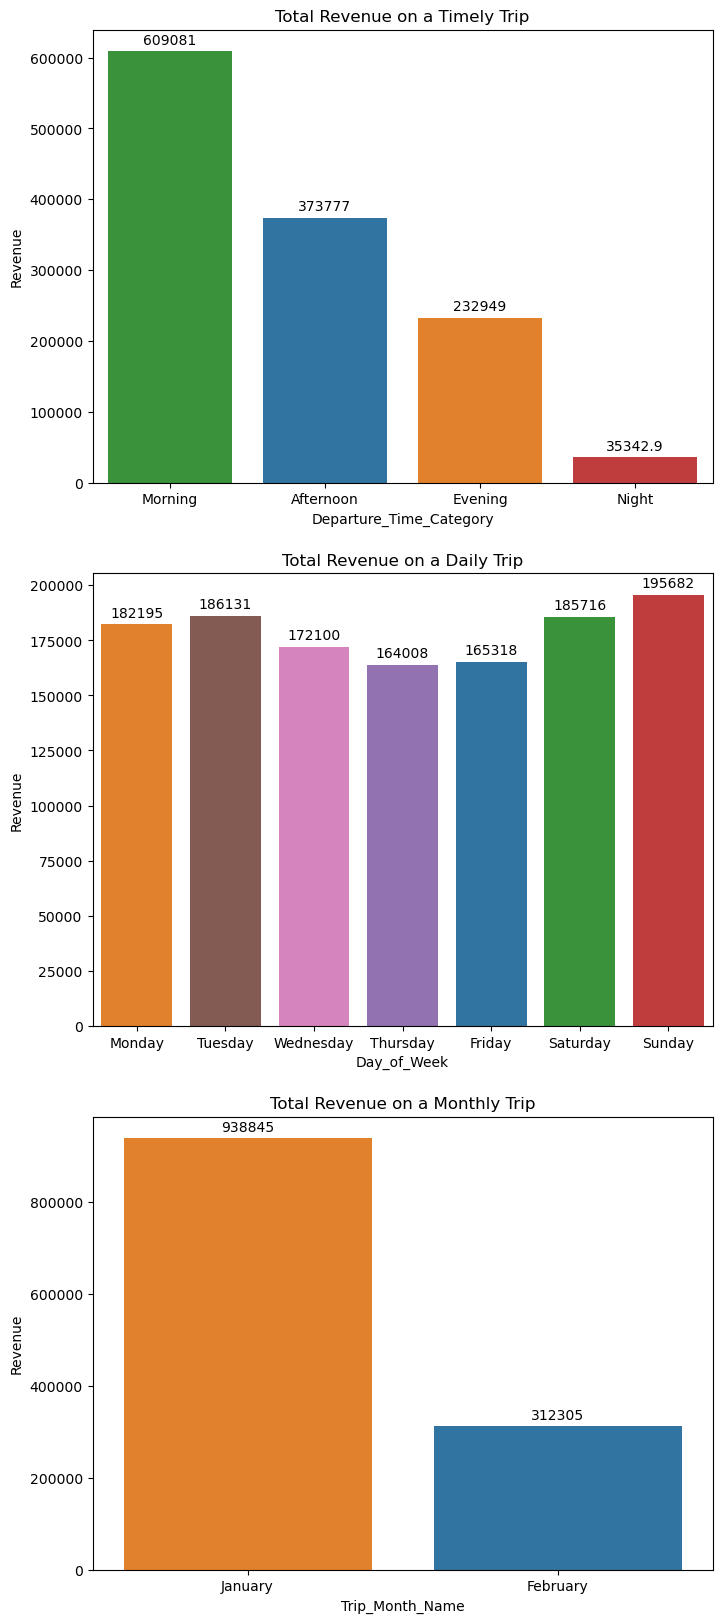

In [54]:
# To know how much revenue on a timely, daily, monthly basis, and Destination;


fig,axs = plt.subplots(nrows = 3, ncols = 1, figsize =(8, 20))

week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February']
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']

timely_revenue = data.groupby('Departure_Time_Category')['Revenue'].sum().reset_index()
sns.barplot(x= 'Departure_Time_Category', data = timely_revenue, y = 'Revenue', hue = 'Departure_Time_Category', order = time_order, ax=axs[0])
for container in axs[0].containers:
    axs[0].bar_label(container,padding =3)
axs[0].set_title('Total Revenue on a Timely Trip');

daily_revenue = data.groupby('Day_of_Week')['Revenue'].sum().reset_index()
sns.barplot(x= 'Day_of_Week', data = daily_revenue, y = 'Revenue', hue = 'Day_of_Week', order = week_order,  ax=axs[1])
for container in axs[1].containers:
    axs[1].bar_label(container,padding =3)
axs[1].set_title('Total Revenue on a Daily Trip');

monthly_revenue = data.groupby('Trip_Month_Name')['Revenue'].sum().reset_index()
sns.barplot(x= 'Trip_Month_Name', data = monthly_revenue, y = 'Revenue', hue = 'Trip_Month_Name', order = month_order,  ax=axs[2])
for container in axs[2].containers:
    axs[2].bar_label(container,padding =3)
axs[2].set_title('Total Revenue on a Monthly Trip');



In [55]:
data['Destination'].value_counts().head(10)

Destination
North Station To Airport     44
Central To Airport           40
Central To North Station     37
Airport To Airport           37
Central To South Point       37
West End To Airport          34
North Station To Downtown    33
Airport To West End          33
Central To Downtown          33
Central To Central           32
Name: count, dtype: int64

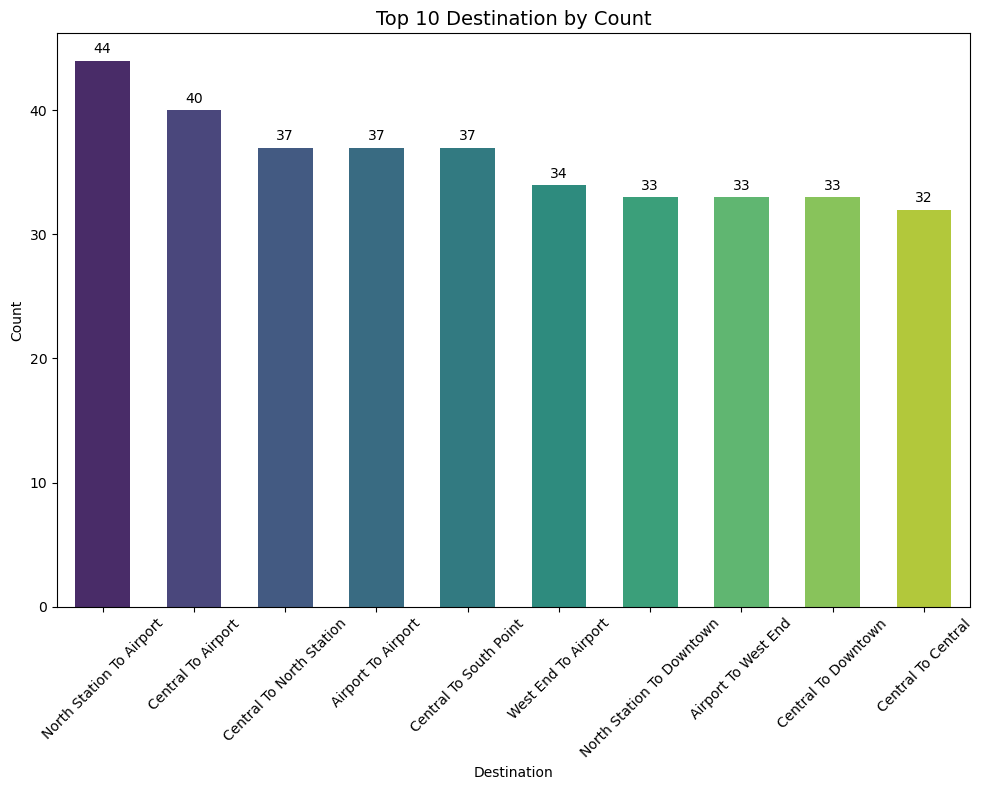

In [56]:
# To visualize it

plt.figure(figsize=(10,8))
topten = data['Destination'].value_counts().head(10)
ax = sns.countplot( x='Destination', data=data, order=topten.index, palette='viridis', width = 0.6)
for container in ax.containers:
    ax.bar_label(container, padding=3)
    plt.title('Top 10 Destination by Count', fontsize=14)
plt.xlabel('Destination')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

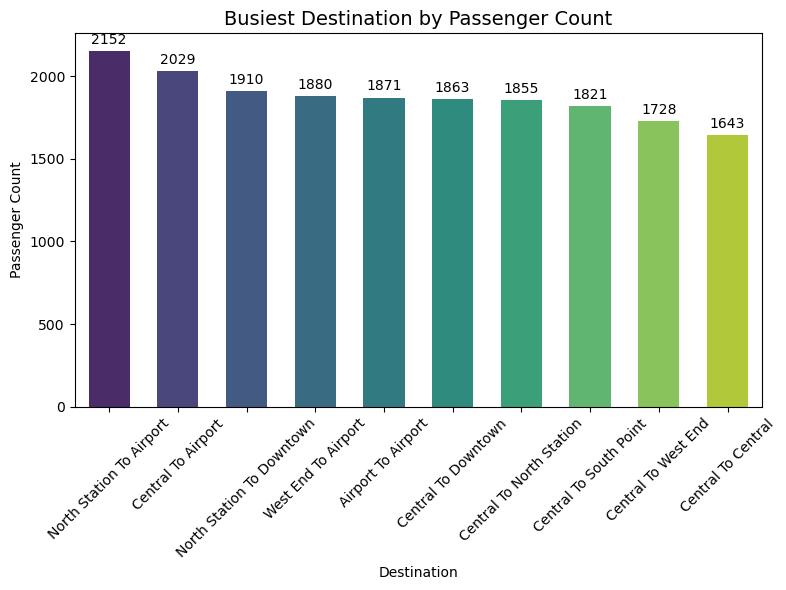

In [57]:
# Busiest Destination(Top ten)- Destination vs Passenger count;

fig, ax = plt.subplots(figsize=(8,6))
busiest_destination = (data.groupby('Destination')['Passenger_Count'] .sum().sort_values(ascending=False).head(10).reset_index())
bar_plot = sns.barplot( x='Destination', y='Passenger_Count', data=busiest_destination, hue='Destination', palette='viridis', width=0.6, ax=ax)
for container in bar_plot.containers:
    bar_plot.bar_label(container, padding=3)
ax.set_title('Busiest Destination by Passenger Count', fontsize=14)
ax.set_xlabel('Destination')
ax.set_ylabel('Passenger Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();


In [58]:
data['Mode_of_Transport'].value_counts()

Mode_of_Transport
Bus      332
Ferry    287
Train    243
Tram     138
Name: count, dtype: int64

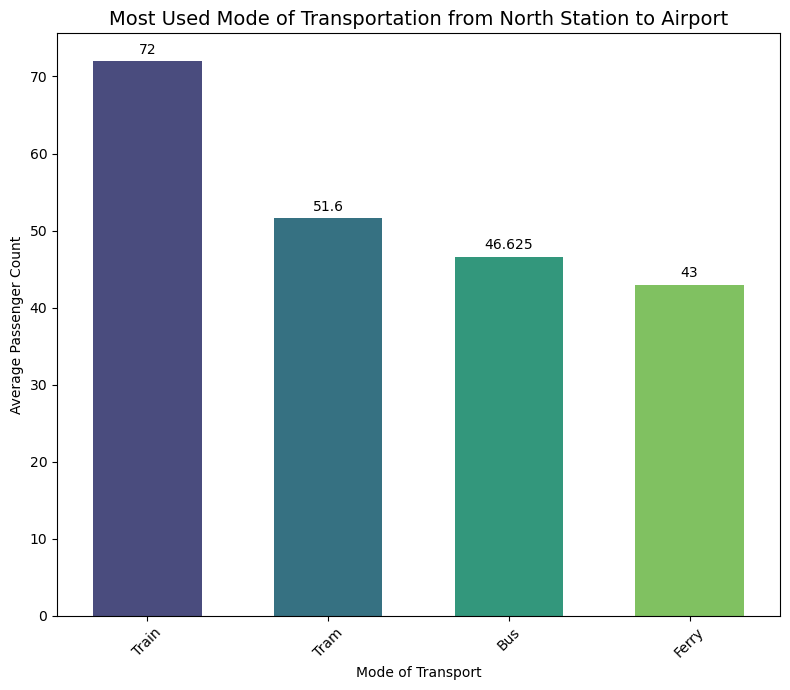

In [59]:
#Most used Mode of Transportation to the Busiest Destination;

fig, ax = plt.subplots(figsize=(8,7))
df = data.query('Destination == "North Station To Airport"')
busiest_destination = df.groupby('Mode_of_Transport')['Passenger_Count'].mean().sort_values(ascending=False).head(10).reset_index()
bar_plot = sns.barplot( x='Mode_of_Transport', y='Passenger_Count', data=busiest_destination, hue='Mode_of_Transport', palette='viridis', width=0.6, ax=ax)
for container in bar_plot.containers:
    bar_plot.bar_label(container, padding=3)
ax.set_title('Most Used Mode of Transportation from North Station to Airport', fontsize=14)
ax.set_xlabel('Mode of Transport')
ax.set_ylabel('Average Passenger Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

In [60]:
# Fastest Mode of Transportation- Mode of Transport vs Trip Duration Minutes;

fastest_mt = data.groupby('Mode_of_Transport')['Trip_Duration_Minutes'].mean().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(fastest_mt, x= 'Mode_of_Transport', y = 'Trip_Duration_Minutes',text_auto = True, color ='Mode_of_Transport',  title='Average Trip Duration by Mode of Transport')
fig.update_xaxes(categoryorder = 'array', categoryarray = ['Train', 'Tram', 'Bus', 'Ferry'])

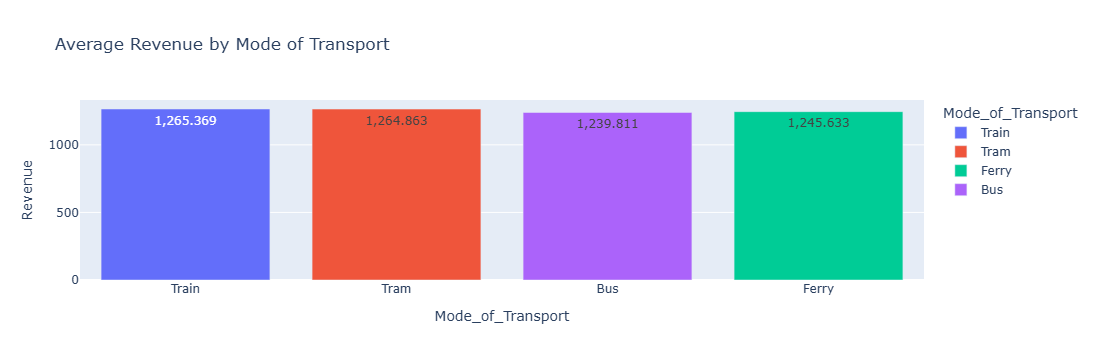

In [61]:
# Mode of Transportation with the highest Revenue- Mode of Transport vs Revenue;

revenue_mt = data.groupby('Mode_of_Transport')['Revenue'].mean().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(revenue_mt, x= 'Mode_of_Transport', y = 'Revenue',text_auto = True, color ='Mode_of_Transport', title = 'Average Revenue by Mode of Transport')
fig.update_xaxes(categoryorder = 'array', categoryarray = ['Train', 'Tram', 'Bus', 'Ferry'])

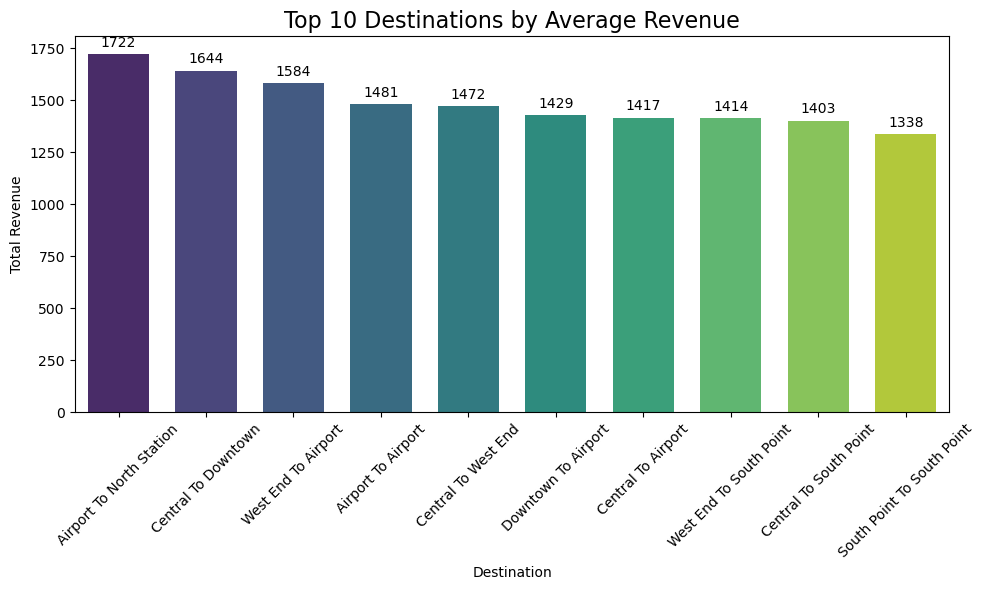

In [62]:
# Average Revenue by Destination (top ten);

fig, ax = plt.subplots(figsize=(10,6))
top10_revenue = (data.groupby('Destination')['Revenue'].mean().sort_values(ascending=False).head(10).reset_index())
bar_plot = sns.barplot(x='Destination', y='Revenue', data=top10_revenue, hue='Destination', palette='viridis', width=0.7, ax=ax)
for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.0f', padding=3)
ax.set_title('Top 10 Destinations by Average Revenue', fontsize=16)
ax.set_xlabel('Destination')
ax.set_ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show(); 

#### Multivariate Analysis;

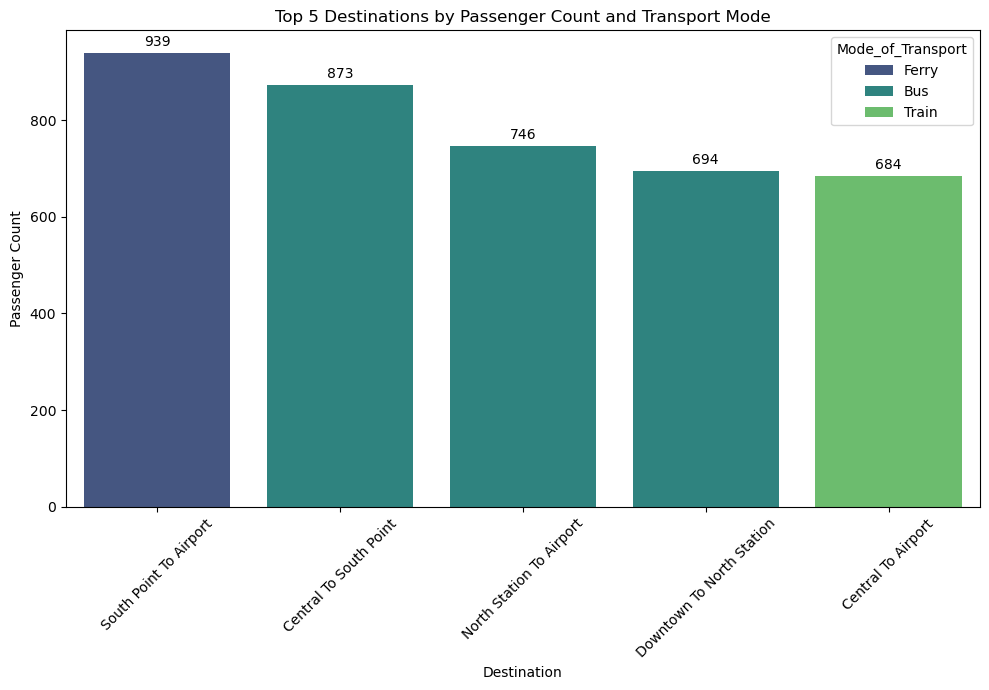

In [78]:
# To analyze used mode of transport per destination(top 5) and passenger movement pattern- Destination vs Mode of Transport
# vs Passenger Count;

plt.figure(figsize=(10,7))

top5_dest = data.groupby(['Destination','Mode_of_Transport'])['Passenger_Count'].sum().sort_values(ascending=False).head(5).reset_index()
ax = sns.barplot(data = top5_dest, x = 'Destination', y = 'Passenger_Count', hue = 'Mode_of_Transport', palette='viridis',width= 0.8)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Top 5 Destinations by Passenger Count and Transport Mode')
plt.xlabel('Destination')
plt.ylabel('Passenger Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

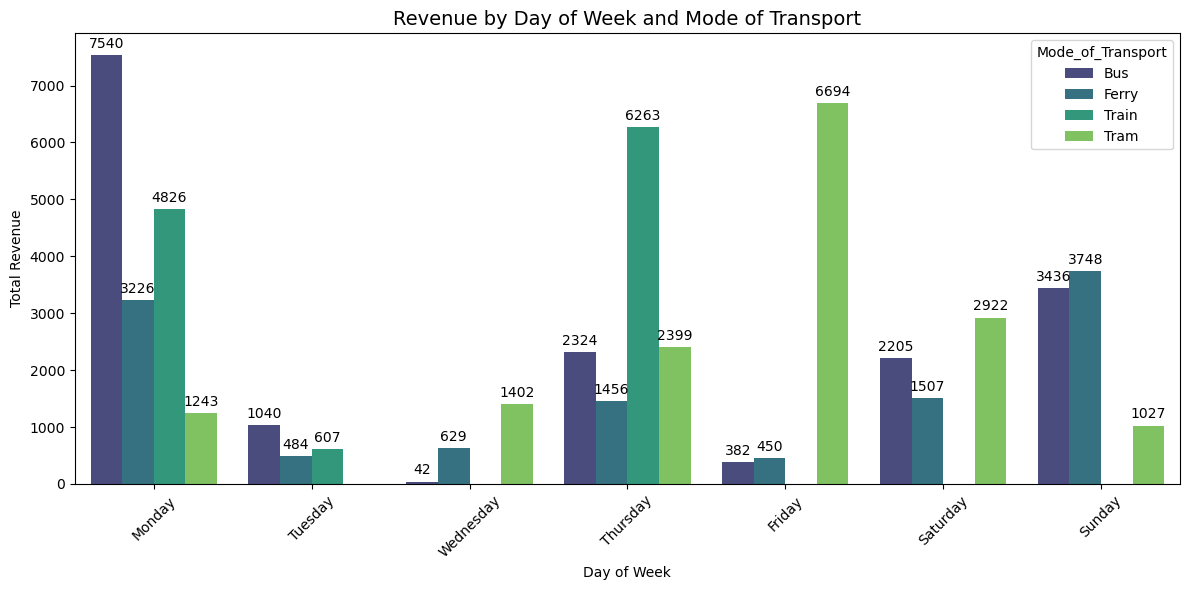

In [84]:
# To know which transport mode earns more on specific days and Peak business periods- Revenue vs Day of Week vs Mode of Transport; 

plt.figure(figsize=(12,6))
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


day_tran_rev = (df.groupby(['Mode_of_Transport', 'Day_of_Week'])['Revenue'].sum().reset_index())
ax = sns.barplot(data=day_tran_rev, x='Day_of_Week', y='Revenue', hue='Mode_of_Transport', palette='viridis', order = week_order)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Revenue by Day of Week and Mode of Transport', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

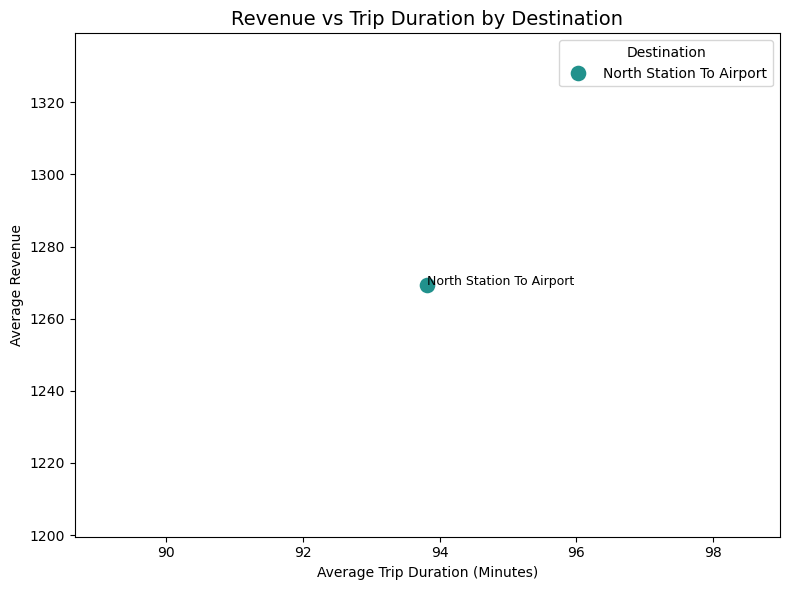

In [94]:
# To know whether longer trips generate more revenue and most efficient routes- Revenue vs Trip Duration Minutes vs Destination; 

plt.figure(figsize=(8,6))
trip_analysis = (df.groupby('Destination')[['Trip_Duration_Minutes', 'Revenue']].mean().reset_index())
sns.scatterplot(data=trip_analysis, x='Trip_Duration_Minutes', y='Revenue', hue='Destination', s=150, palette='viridis')
for i in range(len(trip_analysis)):
    plt.text(
        trip_analysis['Trip_Duration_Minutes'][i],
        trip_analysis['Revenue'][i],
        trip_analysis['Destination'][i],
        fontsize=9
    )
plt.title('Revenue vs Trip Duration by Destination', fontsize=14)
plt.xlabel('Average Trip Duration (Minutes)')
plt.ylabel('Average Revenue')
plt.tight_layout()
plt.show();

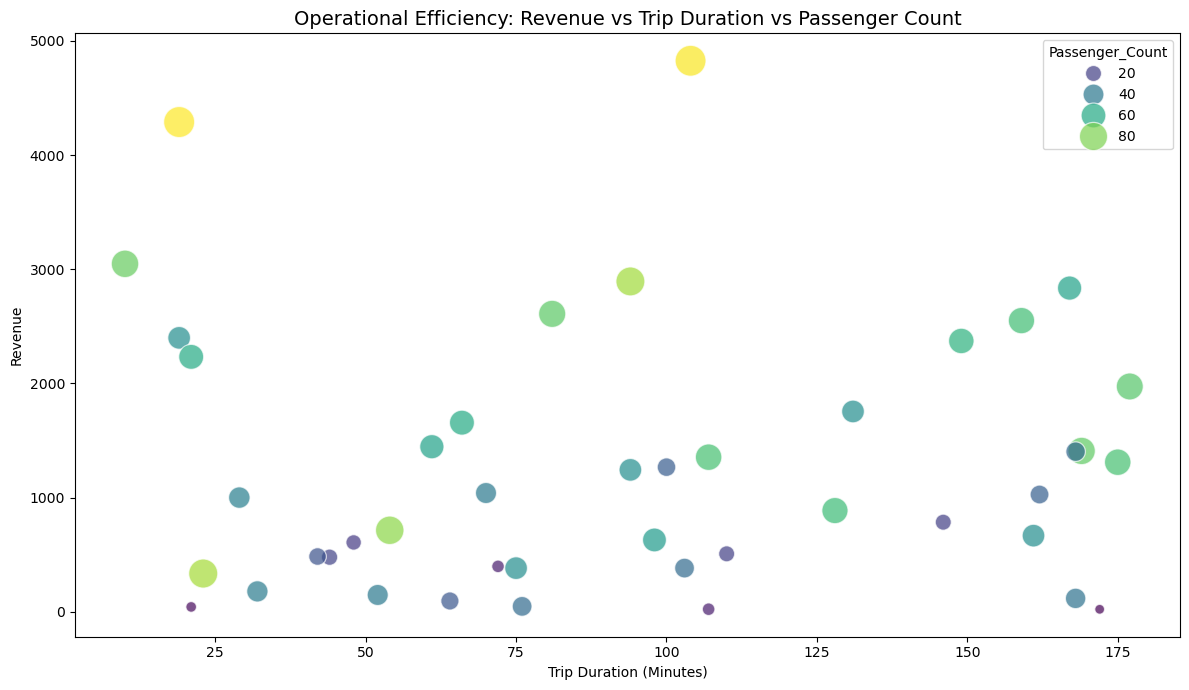

In [96]:
# To know operational efficiency and profitability patterns- Revenue vs Trip Duration Minutes vs Passenger Count; 

plt.figure(figsize=(12,7))
scatter = sns.scatterplot(
    data=df,
    x='Trip_Duration_Minutes',
    y='Revenue',
    size='Passenger_Count',
    hue='Passenger_Count',
    sizes=(50, 500),
    palette='viridis',
    alpha=0.7
)
plt.title('Operational Efficiency: Revenue vs Trip Duration vs Passenger Count', fontsize=14)
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show();



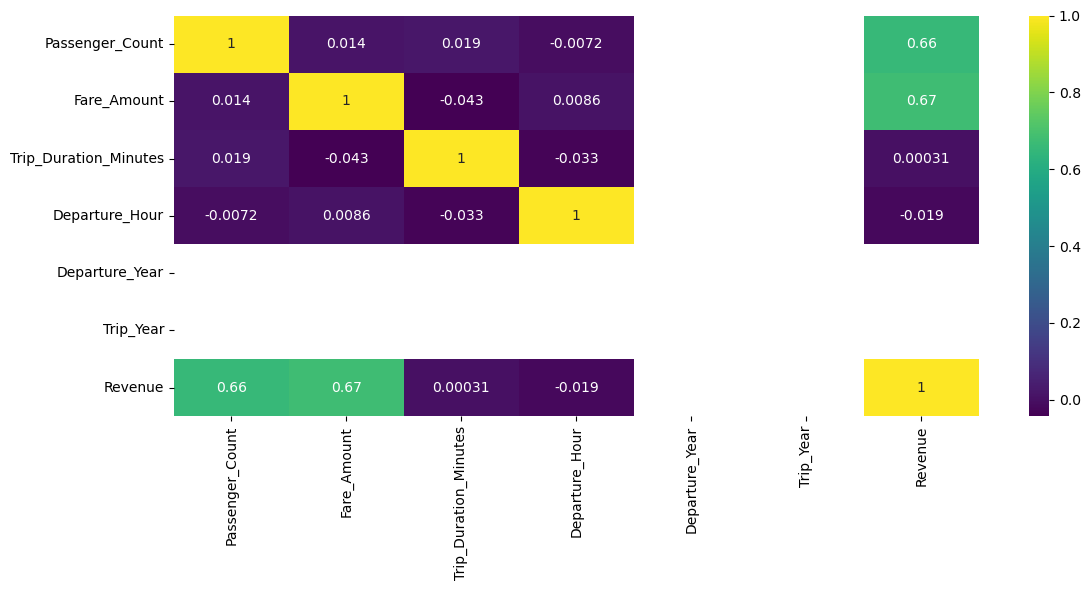

In [95]:
# Heatmap visuslization;

plt.figure(figsize=(12,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='viridis')
plt.tight_layout()
plt.show();